# 05 — SHAP Explainability
**ZivaBasa MVP (Kaggle-Data Phase)**

Runs SHAP against each task head of the multi-task model saved in
`04_multitask_neural_network.ipynb`, producing:

- Global feature importance (which features drive predictions overall, per task)
- Local explanations for individual instances (why *this* employee got *this* score)
- Waterfall + summary plots for each task head

> This notebook implements **standard (associational) SHAP**, not the causal-consistent XAI
> layer described in the ChiedzaAI proposal — that remains a later research milestone (see
> README, Section 7, Known Limitations).

**Input:** `models/multitask_model/{task}_model.keras` + processed features
**Output:** `models/shap_outputs/{task}_shap_values.npy`, feature importance CSVs, plots


In [1]:
# --- Setup ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
import shap

pd.set_option("display.max_columns", 100)
tf.random.set_seed(42)
np.random.seed(42)
shap.initjs()

PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models/multitask_model"
SHAP_DIR = "../models/shap_outputs"
os.makedirs(SHAP_DIR, exist_ok=True)

print("SHAP:", shap.__version__)
print("TensorFlow:", tf.__version__)


SHAP: 0.45.1
TensorFlow: 2.16.1


## 1. Recreate Test Splits

Uses the **exact same** target/drop-column config and `random_state=42` split as notebooks 03/04,
so the instances explained here are the same ones the models were evaluated on.


In [2]:
TASK_CONFIG = {
    "employment": {
        "target": "target_high_automation_risk",
        "task_type": "classification",
        "drop_cols": ["target_high_automation_risk", "automation_risk_score", "automation_exposure_index", "exposure_x_skill_complexity"],
    },
    "skills": {
        "target": "target_attrition",
        "task_type": "classification",
        "drop_cols": ["target_attrition"],
    },
    "productivity": {
        "target": "target_ai_adoption",
        "task_type": "regression",
        "drop_cols": ["target_ai_adoption", "ai_adoption_level", "ai_adoption_index"],
    },
}

def load_features(name):
    path = os.path.join(PROCESSED_DIR, f"{name}_features.parquet")
    if not os.path.exists(path):
        print(f"[MISSING] {path} — run 02_feature_engineering.ipynb first.")
        return None
    return pd.read_parquet(path)

splits = {}
for name, cfg in TASK_CONFIG.items():
    df = load_features(name)
    if df is None or cfg["target"] not in df.columns:
        print(f"[{name}] skipped — missing data or target.")
        continue

    drop_cols = [c for c in cfg["drop_cols"] if c in df.columns]
    X = df.drop(columns=drop_cols).select_dtypes(include=[np.number]).astype("float32")
    y = df[cfg["target"]].astype("float32")

    stratify = y if cfg["task_type"] == "classification" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=stratify
    )
    splits[name] = {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "feature_names": list(X.columns),
    }
    print(f"[{name}] test set: {X_test.shape[0]:,} rows x {X_test.shape[1]} features")


[employment] test set: 600 rows x 7 features
[skills] test set: 294 rows x 8 features
[productivity] test set: 3,000 rows x 1 features


## 2. Load Trained Task Models


In [3]:
task_models = {}
for name in splits:
    path = os.path.join(MODELS_DIR, f"{name}_model.keras")
    if not os.path.exists(path):
        print(f"[MISSING] {path} — run 04_multitask_neural_network.ipynb first.")
        continue
    task_models[name] = tf.keras.models.load_model(path)
    print(f"[{name}] model loaded from {path}")


[employment] model loaded from ../models/multitask_model\employment_model.keras
[skills] model loaded from ../models/multitask_model\skills_model.keras
[productivity] model loaded from ../models/multitask_model\productivity_model.keras


## 3. Background & Explanation Samples

SHAP needs a background sample (reference distribution) and a sample of instances to explain.
Kept small for speed today — increase `N_BACKGROUND`/`N_EXPLAIN` later for more stable estimates
once this is running end-to-end.


In [4]:
N_BACKGROUND = 100
N_EXPLAIN = 100

shap_inputs = {}
for name, s in splits.items():
    rng = np.random.RandomState(42)
    bg_idx = rng.choice(len(s["X_train"]), size=min(N_BACKGROUND, len(s["X_train"])), replace=False)
    ex_idx = rng.choice(len(s["X_test"]), size=min(N_EXPLAIN, len(s["X_test"])), replace=False)

    background = s["X_train"].iloc[bg_idx].values.astype("float32")
    explain_set = s["X_test"].iloc[ex_idx].values.astype("float32")

    shap_inputs[name] = {
        "background": background,
        "explain_set": explain_set,
        "explain_df": s["X_test"].iloc[ex_idx].reset_index(drop=True),
    }
    print(f"[{name}] background={background.shape[0]} explain_set={explain_set.shape[0]}")


[employment] background=100 explain_set=100
[skills] background=100 explain_set=100
[productivity] background=100 explain_set=100


## 4. Compute SHAP Values (per Task Head)

`GradientExplainer` is tried first (works well with TF2 eager Keras models on older Keras/TF
combinations). If it fails for any reason, falls back to `KernelExplainer` on a wrapped
`model.predict` function — slower, but model-agnostic and always works. Multi-output SHAP is
handled per task since each task head is a separate model here (see notebook 04 for why).

**Known, expected failure on TF >= 2.16 / Keras 3:** `GradientExplainer` internally calls
`tf.keras.backend.learning_phase()`, which Keras 3 removed. On this stack it will reliably fail
with an `AttributeError` and fall back to `KernelExplainer` every time — that fallback message is
expected, not a sign anything is broken. What matters is that the fallback itself completes
without error.


In [ ]:
shap_values_by_task = {}
explainer_used = {}

for name, model in task_models.items():
    background = shap_inputs[name]["background"]
    explain_set = shap_inputs[name]["explain_set"]

    print(f"=== {name} ===")
    try:
        explainer = shap.GradientExplainer(model, background)
        sv = explainer.shap_values(explain_set)
        # GradientExplainer on a single-output model may return a list of length 1
        if isinstance(sv, list):
            sv = sv[0]
        sv = np.squeeze(sv)
        explainer_used[name] = "GradientExplainer"
        print(f"  GradientExplainer succeeded. SHAP values shape: {sv.shape}")
    except Exception as e:
        print(f"  GradientExplainer failed ({type(e).__name__}: {e}); falling back to KernelExplainer.")
        # NOTE: reshape(-1), not squeeze() -- squeeze() collapses a (1, 1) prediction batch
        # (which KernelExplainer does pass at points during its internal sampling) all the way
        # down to a 0-d scalar, and shap then crashes trying to index it (model_out[0]).
        # reshape(-1) always keeps at least one dimension, so this can't happen.
        predict_fn = lambda x: model.predict(x, verbose=0).reshape(-1)
        bg_summary = shap.kmeans(background, min(20, background.shape[0]))
        explainer = shap.KernelExplainer(predict_fn, bg_summary)
        sv = explainer.shap_values(explain_set, nsamples=100)
        sv = np.squeeze(np.array(sv))
        explainer_used[name] = "KernelExplainer"
        print(f"  KernelExplainer succeeded. SHAP values shape: {sv.shape}")

    shap_values_by_task[name] = sv

print("\nExplainer used per task:", explainer_used)


=== employment ===


c:\Users\markn\.conda\envs\deep_learning\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: employment_input
Received: inputs=['Tensor(shape=(100, 7))']
  warnings.warn(msg)


  GradientExplainer failed (AttributeError: in user code:

    File "c:\Users\markn\.conda\envs\deep_learning\Lib\site-packages\shap\explainers\_gradient.py", line 231, in grad_graph  *
        phase = tf.keras.backend.learning_phase()

    AttributeError: module 'keras._tf_keras.keras.backend' has no attribute 'learning_phase'
); falling back to KernelExplainer.


  0%|          | 0/100 [00:00<?, ?it/s]

  KernelExplainer succeeded. SHAP values shape: (100, 7)
=== skills ===
  GradientExplainer failed (AttributeError: in user code:

    File "c:\Users\markn\.conda\envs\deep_learning\Lib\site-packages\shap\explainers\_gradient.py", line 231, in grad_graph  *
        phase = tf.keras.backend.learning_phase()

    AttributeError: module 'keras._tf_keras.keras.backend' has no attribute 'learning_phase'
); falling back to KernelExplainer.


c:\Users\markn\.conda\envs\deep_learning\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: skills_input
Received: inputs=['Tensor(shape=(100, 8))']
  warnings.warn(msg)


  0%|          | 0/100 [00:00<?, ?it/s]

## 5. Global Feature Importance — Summary Plots

Beeswarm-style summary plot per task head: which features push predictions up/down across the
explained sample, and by how much.


=== employment — SHAP Summary Plot ===


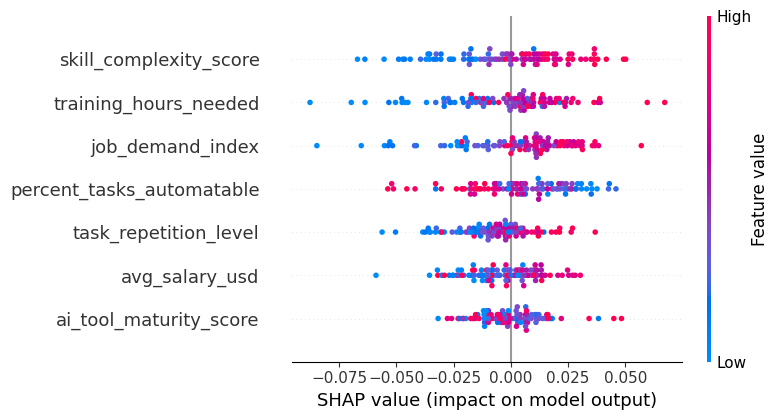

=== skills — SHAP Summary Plot ===


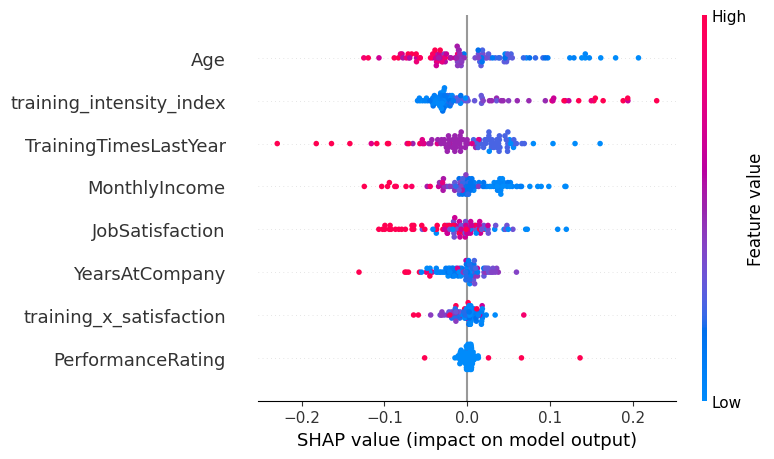

=== productivity — SHAP Summary Plot ===


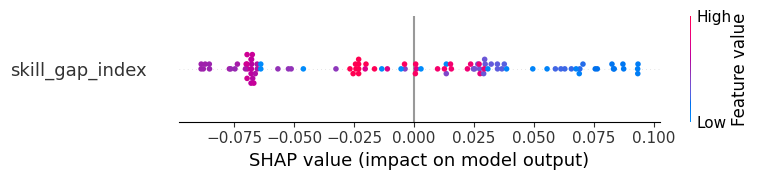

In [ ]:
for name, sv in shap_values_by_task.items():
    feature_names = splits[name]["feature_names"]
    explain_df = shap_inputs[name]["explain_df"]

    print(f"=== {name} — SHAP Summary Plot ===")
    sv_plot = sv.reshape(-1, 1) if np.ndim(sv) == 1 else sv
    shap.summary_plot(sv_plot, explain_df, feature_names=feature_names, show=True)


## 6. Global Feature Importance — Ranked Bar Chart + Table

Mean absolute SHAP value per feature — a simpler, report-friendly ranking to sit alongside the
beeswarm plots above.


=== employment — Top 15 Features by Mean |SHAP| ===


,feature,mean_abs_shap
0,skill_complexity_score,0.020197
1,training_hours_needed,0.019079
2,job_demand_index,0.019016
3,percent_tasks_automatable,0.017666
4,task_repetition_level,0.013053
5,avg_salary_usd,0.012510
6,ai_tool_maturity_score,0.010611


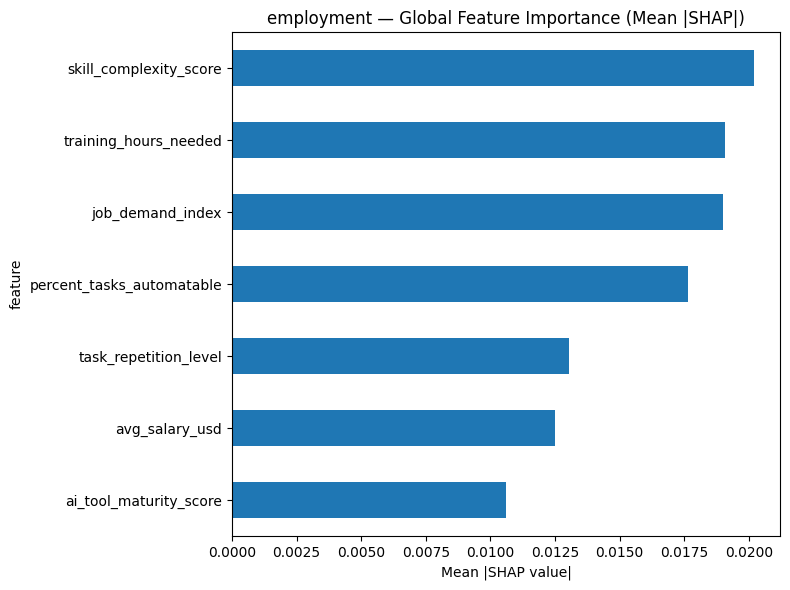

=== skills — Top 15 Features by Mean |SHAP| ===


,feature,mean_abs_shap
0,Age,0.051019
1,training_intensity_index,0.047678
2,TrainingTimesLastYear,0.042264
3,MonthlyIncome,0.032545
4,JobSatisfaction,0.031402
5,YearsAtCompany,0.020888
6,training_x_satisfaction,0.012406
7,PerformanceRating,0.007053


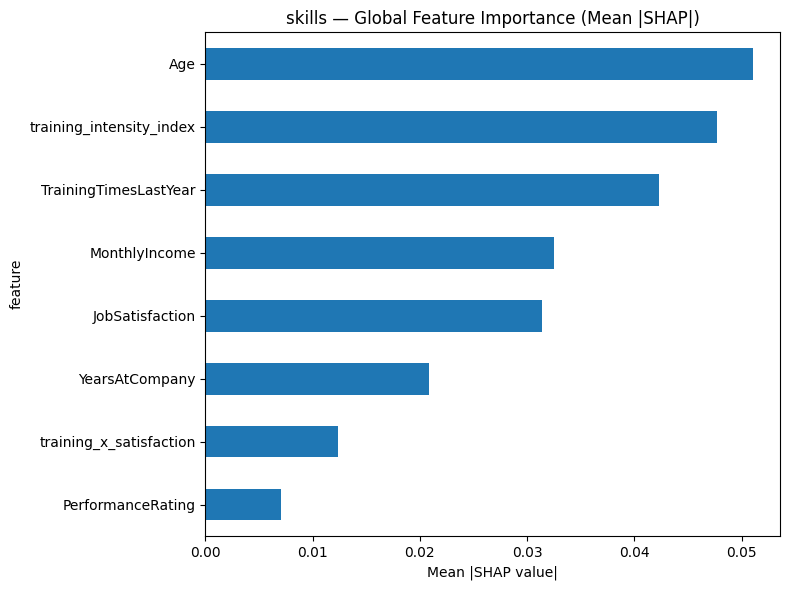

=== productivity — Top 15 Features by Mean |SHAP| ===


,feature,mean_abs_shap
0,skill_gap_index,0.048357


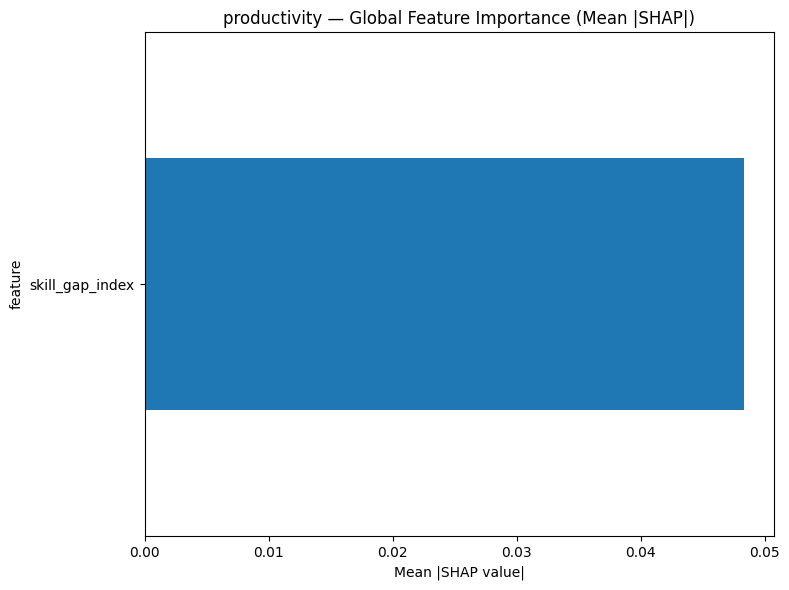

In [ ]:
importance_tables = {}

for name, sv in shap_values_by_task.items():
    feature_names = splits[name]["feature_names"]
    mean_abs_shap = np.abs(sv).mean(axis=0)
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap,
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    importance_tables[name] = imp_df

    print(f"=== {name} — Top 15 Features by Mean |SHAP| ===")
    display(imp_df.head(15))

    plt.figure(figsize=(8, 6))
    imp_df.head(15).set_index("feature")["mean_abs_shap"].sort_values().plot(kind="barh")
    plt.title(f"{name} — Global Feature Importance (Mean |SHAP|)")
    plt.xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.show()


## 7. Local Explanations — Waterfall Plots

Explains individual predictions — e.g. "why did this specific employee get this automation-risk
score / attrition probability / AI-adoption estimate?" This is the piece that makes the model's
outputs defensible to an HR decision-maker rather than a black box.


=== employment — Local Explanation for Instance 0 ===


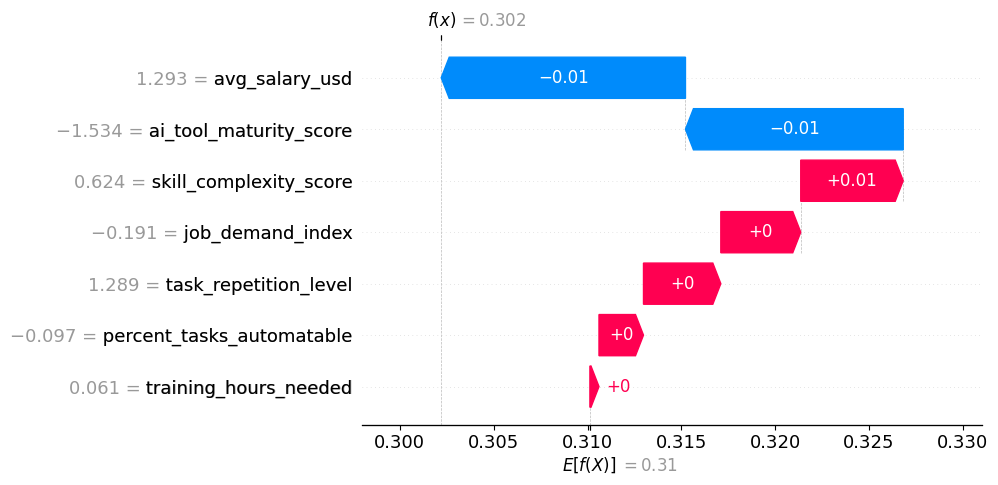

=== skills — Local Explanation for Instance 0 ===


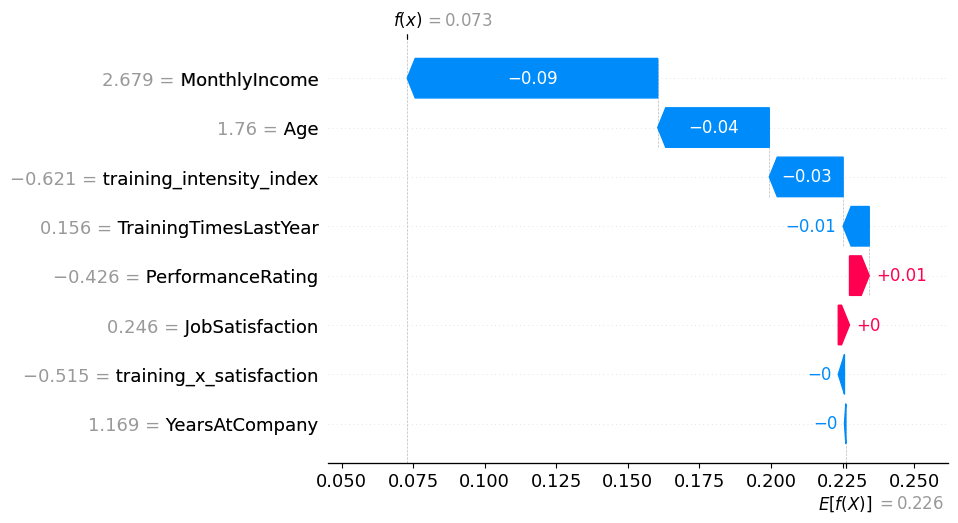

=== productivity — Local Explanation for Instance 0 ===


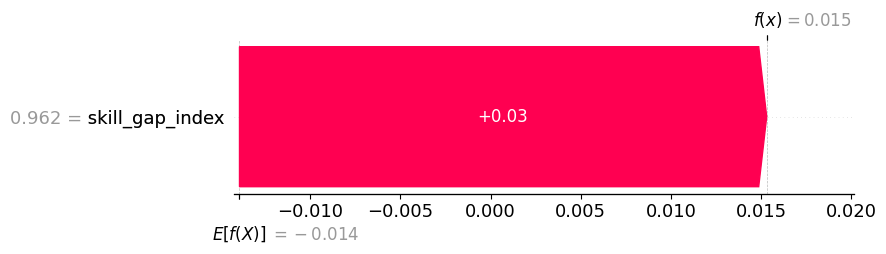

In [ ]:
def plot_waterfall(task_name, instance_idx=0):
    sv = shap_values_by_task[task_name]
    feature_names = splits[task_name]["feature_names"]
    explain_df = shap_inputs[task_name]["explain_df"]
    model = task_models[task_name]

    base_value = float(model.predict(shap_inputs[task_name]["background"], verbose=0).mean())
    instance_values = np.atleast_1d(explain_df.iloc[instance_idx].values)
    instance_shap = np.atleast_1d(sv[instance_idx])

    explanation = shap.Explanation(
        values=instance_shap,
        base_values=base_value,
        data=instance_values,
        feature_names=feature_names,
    )
    print(f"=== {task_name} — Local Explanation for Instance {instance_idx} ===")
    shap.plots.waterfall(explanation, show=True)

# One example instance per task head — change instance_idx to inspect others
for name in shap_values_by_task:
    plot_waterfall(name, instance_idx=0)


## 8. Interpretation Notes (Fill In After Reviewing Plots)

This is the section that turns SHAP output into something an HR stakeholder can act on. Fill in
per task head after reviewing Sections 5–7:

**Employment / Automation Risk**
- Top drivers: _(fill in top 3–5 features from Section 6)_
- Do they make domain sense, or hint at a data-quality/leakage issue?
- Any feature dominating unexpectedly? (worth re-checking `02_feature_engineering.ipynb`, Section 9)

**Skills / Attrition**
- Top drivers: _(fill in)_
- Consistent with the classical baseline's feature importances from `03_baseline_models.ipynb`,
  Section 8? If SHAP and the tree-based importances disagree sharply, that's worth investigating.

**Productivity / AI Adoption**
- Top drivers: _(fill in)_
- Regression targets can be noisier to explain locally — check a handful of waterfall plots
  before trusting a single instance's story.

> Remember: on Kaggle proxy data, these are **methodological validations of the pipeline**, not
> claims about real Zimbabwean banking workforce dynamics (README, Section 1).


## 9. Save SHAP Outputs


In [ ]:
for name, sv in shap_values_by_task.items():
    np.save(os.path.join(SHAP_DIR, f"{name}_shap_values.npy"), sv)
    shap_inputs[name]["explain_df"].to_parquet(
        os.path.join(SHAP_DIR, f"{name}_explained_instances.parquet"), index=False
    )
    importance_tables[name].to_csv(
        os.path.join(SHAP_DIR, f"{name}_feature_importance.csv"), index=False
    )
    print(f"[{name}] SHAP values, explained instances, and importance table saved "
          f"(explainer: {explainer_used[name]})")


[employment] SHAP values, explained instances, and importance table saved (explainer: KernelExplainer)
[skills] SHAP values, explained instances, and importance table saved (explainer: KernelExplainer)
[productivity] SHAP values, explained instances, and importance table saved (explainer: KernelExplainer)


## 10. Summary — MVP Phase Wrap-Up

- [ ] Global feature importance reviewed per task head — top features make domain sense
- [ ] At least one local (waterfall) explanation reviewed per task head for plausibility
- [ ] SHAP importances cross-checked against baseline tree-model importances (notebook 03) —
      note agreements/disagreements in Section 8
- [ ] `explainer_used` noted per task — if any task fell back to `KernelExplainer`, that's slower
      and approximate; worth debugging the `GradientExplainer` failure later if this becomes a
      recurring pipeline
- [ ] All Known Limitations from the README (Section 7) still hold and are documented wherever
      these results get written up — cross-dataset alignment, no Zimbabwe/banking specificity,
      no federated learning yet, standard (not causal-consistent) SHAP

**This completes the Kaggle-data-phase MVP pipeline**: 01 (data) → 02 (features) → 03 (baselines)
→ 04 (multi-task NN) → 05 (explainability). Next phase per the README, Section 8: swap in real
bank data, keep the same architecture and feature taxonomy.
